# 03_ABCD_Rule_Explainability.ipynb
**Mục tiêu:** Mô phỏng lại hệ thống chấm điểm y khoa (Total Dermoscopy Score) XAI.

## 0. Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(r'd:\Computer Vision Final Project\Src code')
from src.features import calculate_A, calculate_B, calculate_C, calculate_D, evaluate_abcd_rule
img = cv2.imread(r'd:\Computer Vision Final Project\Src code\data\train\images\ISIC_0000029.jpg')
img = cv2.resize(img, (600, 450))
mask = cv2.imread(r'd:\Computer Vision Final Project\Src code\data\train\masks\ISIC_0000029_segmentation.png', 0)
mask = cv2.resize(mask, (600, 450))


## 1. Trực quan hóa chữ A (Asymmetry)

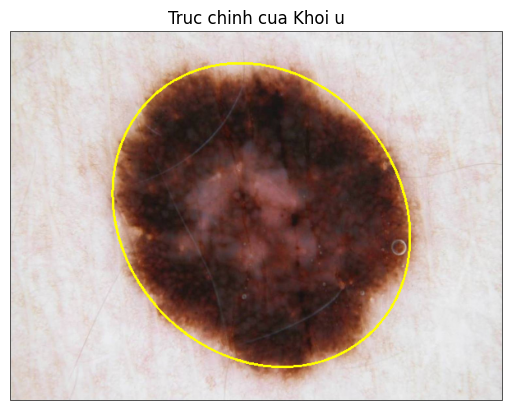

Diem A tinh toan duoc: 2


In [2]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)
(cX, cY), (MA, ma), angle = cv2.fitEllipse(cnt)
img_ellipse = img.copy()
cv2.ellipse(img_ellipse, ((cX, cY), (MA, ma), angle), (0, 255, 255), 2)
plt.imshow(cv2.cvtColor(img_ellipse, cv2.COLOR_BGR2RGB)); plt.title('Truc chinh cua Khoi u'); plt.axis('off'); plt.show()
print(f"Diem A tinh toan duoc: {calculate_A(mask)}")

## 2. Trực quan hóa chữ B (Border)

In [3]:
A = cv2.contourArea(cnt)
P = cv2.arcLength(cnt, True)
compactness = (4 * np.pi * A) / (P ** 2)
print("Cong thuc Compactness Index: (4 * pi * Area) / (Perimeter^2)")
print(f"Dien tich: {A}, Chu vi: {P:.2f} -> Compactness = {compactness:.3f}")
print(f"Diem B tinh toan duoc: {calculate_B(mask)}")

Cong thuc Compactness Index: (4 * pi * Area) / (Perimeter^2)
Dien tich: 103272.5, Chu vi: 1504.12 -> Compactness = 0.574
Diem B tinh toan duoc: 8


## 3. Trực quan hóa chữ C (Color)

In [4]:
print("6 mau lam sang: Trang, Do, Nau nhat, Nau dam, Xanh xam, Den")
print(f"Diem C tinh toan duoc: {calculate_C(img, mask)}")

6 mau lam sang: Trang, Do, Nau nhat, Nau dam, Xanh xam, Den
Diem C tinh toan duoc: 3


## 4. Tổng TDS (Total Dermoscopy Score)

In [5]:
result = evaluate_abcd_rule(img, mask, mask)
print(f"=> TONG DIEM TDS: {result['TDS']}")
print("\n==============================")
print(f"     {result['Diagnosis'].upper()}     ")
print("==============================\n")


=> TONG DIEM TDS: 7.4

     MALIGNANT MELANOMA     

